## Import CUDA

In [14]:
from numba import cuda

## Load the image

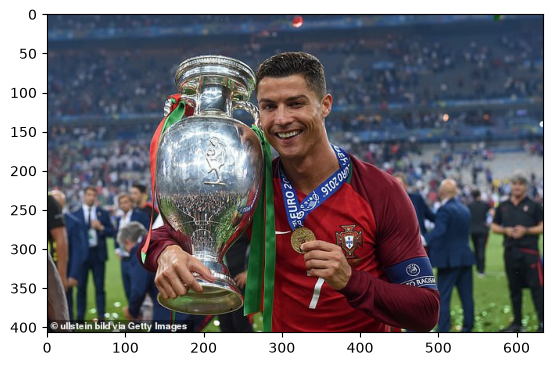

In [15]:
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')
plt.imshow(image)
h, w, d = image.shape

## Grayscale kernel (2D blocks)

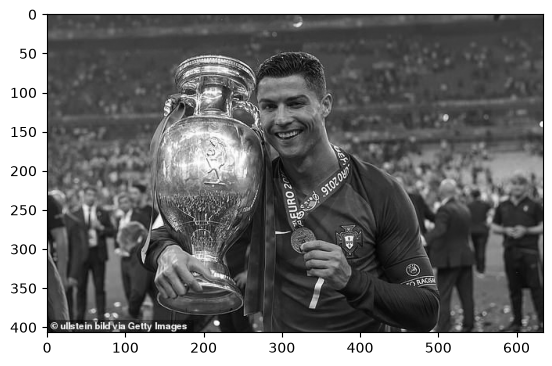

In [16]:
import math
import time
import numpy as np
@cuda.jit
def grayscale2D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return
    g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
    dst[tidy, tidx] = g

blockSize = (32, 32)
gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))

devSrc = cuda.to_device(image)
devGray = cuda.device_array((h, w), np.uint8)
grayscale2D[gridSize, blockSize](devSrc, devGray)
plt.imshow(devGray.copy_to_host(), cmap='gray')

## 7x7 Gaussian blur without shared memory

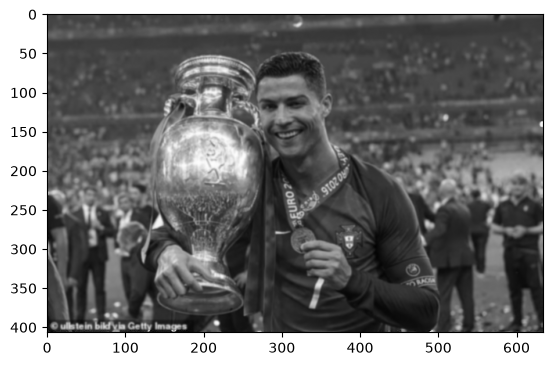

In [17]:
gaussian = np.array([[0, 0, 1, 2, 1, 0, 0],
                     [0, 3, 13, 22, 13, 3, 0],
                     [1, 13, 59, 97, 59, 13, 1],
                     [2, 22, 97, 159, 97, 22, 2],
                     [1, 13, 59, 97, 59, 13, 1],
                     [0, 3, 13, 22, 13, 3, 0],
                     [0, 0, 1, 2, 1, 0, 0]], np.int32)
devFilter = cuda.to_device(gaussian)

@cuda.jit
def blur(src, dst, filt):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx < 3 or tidy < 3 or tidx >= src.shape[1] - 3 or tidy >= src.shape[0] - 3:
        return
    s = 0
    for i in range(7):
        for j in range(7):
            s += src[tidy + i - 3, tidx + j - 3] * filt[i, j]
    dst[tidy, tidx] = np.uint8(s / 1003)

devBlur = cuda.to_device(devGray.copy_to_host())
blur[gridSize, blockSize](devGray, devBlur, devFilter)
plt.imshow(devBlur.copy_to_host(), cmap='gray')

## 7x7 Gaussian blur with shared memory

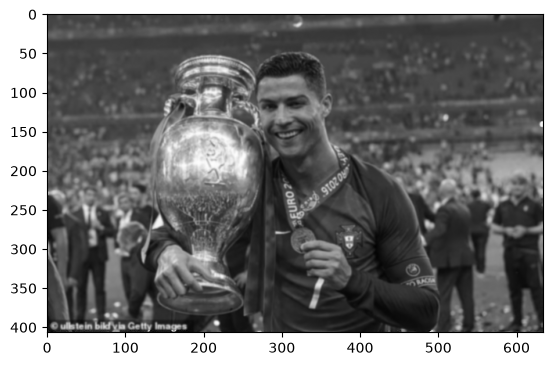

In [18]:
@cuda.jit
def blurShared(src, dst, filt):
    tile = cuda.shared.array((7, 7), np.int32)
    if cuda.threadIdx.x < 7 and cuda.threadIdx.y < 7:
        tile[cuda.threadIdx.x, cuda.threadIdx.y] = filt[cuda.threadIdx.x, cuda.threadIdx.y]
    cuda.syncthreads()

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx < 3 or tidy < 3 or tidx >= src.shape[1] - 3 or tidy >= src.shape[0] - 3:
        return
    s = 0
    for i in range(7):
        for j in range(7):
            s += src[tidy + i - 3, tidx + j - 3] * tile[i, j]
    dst[tidy, tidx] = np.uint8(s / 1003)

devBlurShared = cuda.to_device(devGray.copy_to_host())
blurShared[gridSize, blockSize](devGray, devBlurShared, devFilter)
plt.imshow(devBlurShared.copy_to_host(), cmap='gray')

## Gaussian blur on CPU (baseline)

In [19]:
gray = devGray.copy_to_host()
blurCPU = gray.copy()
start = time.time()
for y in range(3, h - 3):
    for x in range(3, w - 3):
        s = 0
        for i in range(7):
            for j in range(7):
                s += int(gray[y + i - 3, x + j - 3]) * int(gaussian[i, j])
        blurCPU[y, x] = np.uint8(s / 1003)
cpu_time = time.time() - start
cpu_time

4.676799535751343

## Block size vs speedup (with/without shared memory)

Block size: (4, 4)
Grid size: (159, 102)
GPU time: 0.010008573532104492 seconds
GPU time (shared memory): 0.0006787776947021484 seconds
Block size: (8, 8)
Grid size: (80, 51)
GPU time: 0.0005025863647460938 seconds
GPU time (shared memory): 0.0004944801330566406 seconds
Block size: (16, 16)
Grid size: (40, 26)
GPU time: 0.0004477500915527344 seconds
GPU time (shared memory): 0.0001995563507080078 seconds
Block size: (32, 32)
Grid size: (20, 13)
GPU time: 0.00020122528076171875 seconds
GPU time (shared memory): 0.00018262863159179688 seconds


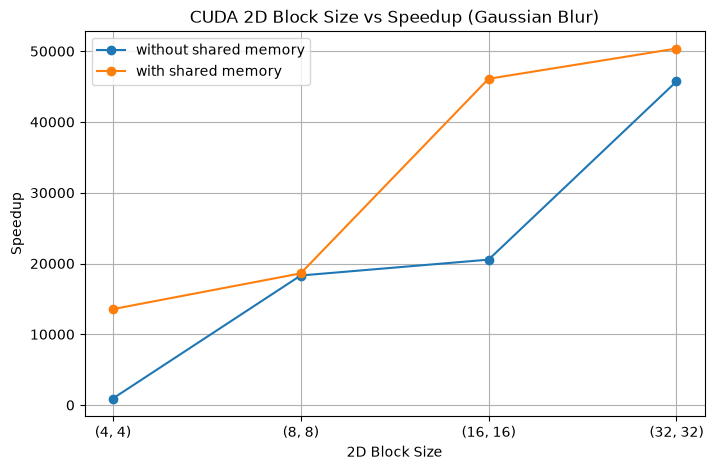

In [11]:
block_sizes = [(4, 4), (8, 8), (16, 16), (32, 32)]
speedups = []
speedupsShared = []

for blockSize in block_sizes:
    gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))

    start = time.time()
    blur[gridSize, blockSize](devGray, devBlur, devFilter)
    cuda.synchronize()
    gpu_time = time.time() - start
    speedups.append(cpu_time / gpu_time)

    start = time.time()
    blurShared[gridSize, blockSize](devGray, devBlurShared, devFilter)
    cuda.synchronize()
    gpu_time_shared = time.time() - start
    speedupsShared.append(cpu_time / gpu_time_shared)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {gpu_time} seconds")
    print(f"GPU time (shared memory): {gpu_time_shared} seconds")

plt.figure(figsize=(8, 5))
plt.plot([str(b) for b in block_sizes], speedups, marker='o', label='without shared memory')
plt.plot([str(b) for b in block_sizes], speedupsShared, marker='o', label='with shared memory')
plt.xlabel("2D Block Size")
plt.ylabel("Speedup")
plt.title("CUDA 2D Block Size vs Speedup (Gaussian Blur)")
plt.legend()
plt.grid(True)
plt.show()